In [1]:
import copy
from pathlib import Path

import gstools as gs
import jax
import jax.numpy as jnp
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import skfmm
from gstools import covmodel
from scipy.io import loadmat
from tqdm.auto import tqdm, trange

from nanopinv.physics import travel_time_points
from nanopinv.prior import CholeskyPrior

jax.config.update("jax_enable_x64", True)

# # ignore plot warnings in gstools
# import warnings
# warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
M = loadmat("AM13_data.mat")
N_data, N_dim = M["S"].shape
sources = M["S"]  # Shape: (N_data, N_dim)
receivers = M["R"]  # Shape: (N_data, N_dim)
assert sources.shape == receivers.shape, (
    "Sources and receivers must have the same shape."
)

data_obs = M["d_obs"].flatten()
data_std = M["d_std"].flatten()
data_std = 0.4 * np.ones_like(
    data_obs
)  # For whatever reason, we overwrite this, maybe original data was wrong?

print(f"Number of data points: {N_data}")
print(f"Number of dimensions: {N_dim}")

Number of data points: 702
Number of dimensions: 2


c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\gstools\field\generator.py:237: UserWarning: gstools.RandMeth: **kwargs are ignored
  warnings.warn("gstools.RandMeth: **kwargs are ignored")


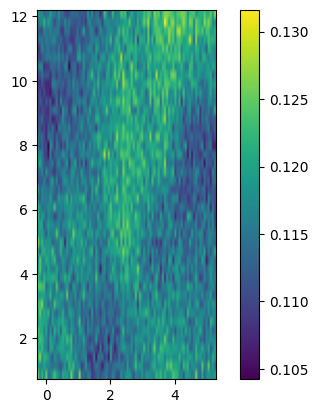

In [3]:
# Set up prior
dx = 0.135

x = np.arange(-2 * dx, 5 + 2 * dx, dx)
y = np.arange(1 - 2 * dx, 12 + 2 * dx, dx)
m0 = 0.12
C_m = covmodel.Spherical(dim=2, var=0.00003, len_scale=7)  # '0.00003 Sph(7)'

# Model parameters: Velocity field


srf = gs.SRF(C_m, mean=m0, generator_kwargs={"mode_no": 50})
samples = srf.structured((x, y))
# samples = srf((r[:, 0], r[:, 1]))

plt.imshow(samples, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis)
plt.colorbar()

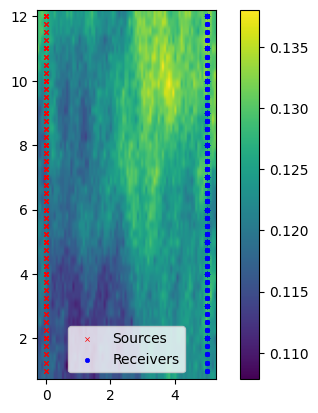

In [4]:
# Forward model
# def travel_time(m):

plt.figure()

realisation = srf.structured((x, y), seed=0)
plt.imshow(
    realisation, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar()

plt.scatter(
    sources[:, 0], sources[:, 1], c="red", marker="x", s=10, lw=0.5, label="Sources"
)
plt.scatter(
    receivers[:, 0],
    receivers[:, 1],
    c="blue",
    marker="o",
    s=10,
    lw=0.5,
    label="Receivers",
)

plt.legend()

In [5]:
receivers
travel_times = travel_time_points(
    [x, y], speeds=realisation, source=sources[55], receivers=receivers, window=1
)


def forward_model(m):
    # Sources and receivers are not unique, but rather set up as a grid
    # For simplicity, we iterate over all sources and compute the receivers for each source, then concatenate appropriate
    travel_times = np.empty(shape=(N_data,))

    unique_sources, inverse_indices = np.unique(sources, axis=0, return_inverse=True)
    for i, u_src in enumerate(unique_sources):
        mask = inverse_indices == i
        associated_receivers = receivers[mask]
        travel_times[mask] = travel_time_points(
            [x, y], speeds=m, source=u_src, receivers=associated_receivers, window=1
        )

    return travel_times

    # # u_sources, u_indices, u_inverse, u_counts = np.unique(sources, axis=0, return_inverse=True, return_index=True)
    # # for u_source, u_index, u_count in zip(u_sources, u_indices, u_counts):
    #     # # source = u_source
    #     # # Indices of this source

    #     # # receivers = receivers[]
    #     # # Get the indices of the data points corresponding to this unique source
    #     # indices = np.where(u_inverse == u_index)[0]
    #     # # Get the corresponding receivers for this source
    #     # u_receivers = receivers[indices]
    #     # # Compute travel times for this source and its corresponding receivers
    #     # travel_times[indices] = travel_time_points([x, y], speeds=m, source=u_source, receivers=u_receivers, window=1)

    # travel_times = travel_time_points([x, y], speeds = m, source=sources[55], receivers=receivers, window=1)


# plt.imshow(travel_times)
# plt.colorbar()

# print

# forward_model(realisation).shape

In [6]:
from typing import Sequence

import jax
import jax.numpy as jnp
import numpy as np
from jax.experimental import checkify
from jax.scipy.interpolate import RegularGridInterpolator
from jaxtyping import Array, Float

receivers_j = jnp.asarray(receivers)
sources_j = jnp.asarray(sources)

In [7]:
# @jax.jit(static_argnames=["radius", "window", "order", "check"])
# @checkify.checkify
# def travel_time_points_jax(
#     r: Sequence[Float[Array, "ax"]],
#     speeds: Float[Array, "..."],
#     source: Float[Array, "ndim"],
#     receivers: Float[Array, "receivers ndim"],
#     radius: float | None = None,
#     window: int = 2,
#     order: int = 2,
#     check: bool = True,
# ):
#     ndim = len(r)
#     shape_grid = tuple(len(arr) for arr in r)

#     if check:
#         # checkify raises if the condition is FALSE.
#         checkify.check(jnp.all(speeds > 0.0), "Speeds must be positive")

#     # Calculate and check the grid spacing
#     dr = []
#     for i, arr in enumerate(r):
#         if len(arr) < 2:
#             raise ValueError("Each grid axis must contain at least two points to determine spacing")

#         d_arr = jnp.diff(arr)
#         if check:
#             checkify.check(jnp.allclose(d_arr, d_arr[0]), "Grid must be equidistant along each axis")

#         dr.append(d_arr[0])

#     dr = jnp.array(dr)

#     # ---------------------------------------------------------
#     # JAX-Compatible Dynamic Slicing (Windowing) Logic
#     # ---------------------------------------------------------
#     phi = jnp.ones(shape=shape_grid)
#     nearest_idx = [jnp.argmin(jnp.abs(r[i] - source[i])) for i in range(ndim)]

#     start_indices = []
#     w_sizes = []
#     local_coords = []

#     for i in range(ndim):
#         # Determine strict static sizes for JAX XLA compilation
#         w_size = min(2 * window + 1, shape_grid[i])
#         w_sizes.append(w_size)

#         # Clamp start index to ensure the window doesn't slice out of bounds
#         start_idx = jnp.clip(nearest_idx[i] - window, 0, shape_grid[i] - w_size)
#         start_indices.append(start_idx)

#         # Extract the local coordinate slice for this axis
#         local_c = jax.lax.dynamic_slice_in_dim(r[i], start_idx, w_size)
#         local_coords.append(local_c)

#     # Compute Euclidean distance ONLY within the local window using broadcasting
#     local_phi = jnp.zeros(tuple(w_sizes))
#     for i in range(ndim):
#         shape = [1] * ndim
#         shape[i] = w_sizes[i]
#         c_reshaped = local_coords[i].reshape(shape)
#         local_phi += (c_reshaped - source[i]) ** 2

#     local_phi = jnp.sqrt(local_phi)

#     radius_val = radius if radius is not None else 0.5 * jnp.max(dr)
#     local_phi -= radius_val

#     # Inject the computed local window back into the global phi array
#     phi = jax.lax.dynamic_update_slice(phi, local_phi, tuple(start_indices))
#     # ---------------------------------------------------------

#     # Call scikit-fmm using a pure_callback to bypass JAX tracing
#     result_shape = jax.ShapeDtypeStruct(shape_grid, phi.dtype)
#     travel_times_full = jax.pure_callback(
#         _skfmm_caller,
#         result_shape, # Expected output shape/dtype pre-requisite for XLA
#         phi, speeds, dr, order,
#         vmap_method="broadcast_all",
#     )

#     # Restored RegularGridInterpolator
#     interpolator = RegularGridInterpolator(
#         points=r, values=travel_times_full, bounds_error=False, fill_value=jnp.inf
#     )
#     receiver_travel_times = interpolator(receivers)

#     return receiver_travel_times


In [8]:
# def build_forward_model_jax(sources, receivers):
#     unique_sources, inverse_indices = np.unique(sources, axis=0, return_inverse=True)

#     @jax.jit
#     def forward_model(m):
#         travel_times = jnp.empty(shape=(N_data,))
#         for i, u_src in enumerate(unique_sources):
#             mask = (inverse_indices == i)
#             associated_receivers = receivers[mask]
#             travel_times = travel_time_points_jax([x, y], speeds=m, source=u_src, receivers=associated_receivers, window=1)
#         return travel_times

#     return forward_model


# # def forward_model_jax(m, sources=sources_j, receivers=receivers_j):
# #     # Sources and receivers are not unique, but rather set up as a grid
# #     # For simplicity, we iterate over all sources and compute the receivers for each source, then concatenate appropriate
# #     travel_times = jnp.empty(shape=(N_data,))

# #     unique_sources, inverse_indices = jnp.unique(sources_j, axis=0, return_inverse=True)
# #     for i, u_src in enumerate(unique_sources):
# #         mask = (inverse_indices == i)
# #         associated_receivers = receivers_j[mask]
# #         travel_times = travel_time_points([x, y], speeds=m, source=u_src, receivers=associated_receivers, window=1)

# #     return travel_times

# print(realisation)
# forward_model_jax = build_forward_model_jax(sources_j, receivers_j)

# err, travel_times = forward_model_jax(realisation)
# err.throw()


# # jnp.all(realisation > 0.0)

In [10]:
import statistics as stats
import time

import jax
import jax.numpy as jnp
import numpy as np
import polars as pl

from nanopinv.physics_jax import build_time_travel_points

# Fair dtype setup
m_np = np.asarray(realisation, dtype=np.float32)
m_jax = jnp.asarray(realisation, dtype=jnp.float32)

x_j = jnp.asarray(x, dtype=jnp.float32)
y_j = jnp.asarray(y, dtype=jnp.float32)
sources_j = jnp.asarray(sources, dtype=jnp.float32)
receivers_j = jnp.asarray(receivers, dtype=jnp.float32)

# # IMPORTANT:
# # - no boolean masking on traced arrays inside jit
# # - precompute concrete integer index groups outside jit
# def build_forward_model_jax(sources_j, receivers_j):
#     sources_np = np.asarray(sources_j)
#     receivers_np = np.asarray(receivers_j)

#     unique_sources_np, inverse_np = np.unique(
#         sources_np, axis=0, return_inverse=True
#     )

#     groups = []
#     for i in range(unique_sources_np.shape[0]):
#         idx_i = np.where(inverse_np == i)[0].astype(np.int32)  # concrete indices
#         src_i = jnp.asarray(unique_sources_np[i], dtype=jnp.float32)
#         rec_i = jnp.asarray(receivers_np[idx_i], dtype=jnp.float32)
#         groups.append((idx_i, src_i, rec_i))

#     @jax.jit
#     def forward_model_jax_impl(m):
#         out = jnp.empty((N_data,), dtype=m.dtype)

#         # Python loop over static groups is ok; compiled once
#         for idx_i, src_i, rec_i in groups:
#             err_i, tt_i = travel_time_points_jax(
#                 [x_j, y_j],
#                 speeds=m,
#                 source=src_i,
#                 receivers=rec_i,
#                 window=1,
#                 check=False,  # benchmark mode
#             )
#             out = out.at[idx_i].set(tt_i)

#         return out

#     return forward_model_jax_impl

forward_model_jax = build_time_travel_points(sources_j, receivers_j, x_j, y_j)


def bench_numpy(fn, n_warmup=2, n_runs=10):
    for _ in range(n_warmup):
        _ = fn()
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        _ = fn()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return times


def bench_jax(fn, n_warmup=2, n_runs=10):
    for _ in range(n_warmup):
        y = fn()
        y.block_until_ready()

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        y = fn()
        y.block_until_ready()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return times


def np_fwd_call():
    return forward_model(m_np)


def jax_fwd_call():
    return forward_model_jax(m_jax)


np_fwd_times = bench_numpy(np_fwd_call, n_warmup=5, n_runs=100)
jax_fwd_times = bench_jax(jax_fwd_call, n_warmup=5, n_runs=100)

df_fwd = pl.DataFrame(
    {
        "impl": ["numpy_forward", "jax_forward"],
        "mean_ms": [1e3 * stats.mean(np_fwd_times), 1e3 * stats.mean(jax_fwd_times)],
        "median_ms": [
            1e3 * stats.median(np_fwd_times),
            1e3 * stats.median(jax_fwd_times),
        ],
        "min_ms": [1e3 * min(np_fwd_times), 1e3 * min(jax_fwd_times)],
        "max_ms": [1e3 * max(np_fwd_times), 1e3 * max(jax_fwd_times)],
    }
)

print(df_fwd)
print(
    "Forward speedup (numpy / jax, mean): {:.3f}x".format(
        stats.mean(np_fwd_times) / stats.mean(jax_fwd_times)
    )
)

shape: (2, 5)
┌───────────────┬───────────┬───────────┬─────────┬──────────┐
│ impl          ┆ mean_ms   ┆ median_ms ┆ min_ms  ┆ max_ms   │
│ ---           ┆ ---       ┆ ---       ┆ ---     ┆ ---      │
│ str           ┆ f64       ┆ f64       ┆ f64     ┆ f64      │
╞═══════════════╪═══════════╪═══════════╪═════════╪══════════╡
│ numpy_forward ┆ 68.058721 ┆ 63.0536   ┆ 55.2764 ┆ 177.1488 │
│ jax_forward   ┆ 39.266401 ┆ 40.9161   ┆ 29.3166 ┆ 46.4874  │
└───────────────┴───────────┴───────────┴─────────┴──────────┘
Forward speedup (numpy / jax, mean): 1.733x


In [ ]:
# # SNIPPET 1/4: update inside travel_time_points_jax
# # Replace vmap_method with "broadcast_all" in your jax.pure_callback call:
# # travel_times_full = jax.pure_callback(
# #     _skfmm_caller,
# #     result_shape,
# #     phi, speeds, dr, order,
# #     vmap_method="broadcast_all",
# # )

# # SNIPPETS 2+3+4 merged: grouping + vmapped forward model + benchmark

# import time
# import statistics as stats
# import numpy as np
# import polars as pl
# import jax
# import jax.numpy as jnp

# # Build grouped source/receiver tensors once
# unique_sources_np, inverse_np = np.unique(sources, axis=0, return_inverse=True)
# groups = [np.where(inverse_np == i)[0].astype(np.int32) for i in range(len(unique_sources_np))]

# S = len(groups)
# Kmax = max(len(g) for g in groups)
# D = receivers.shape[1]

# sources_u_np = np.asarray(unique_sources_np, dtype=np.float32)          # [S, D]
# recv_pad_np = np.zeros((S, Kmax, D), dtype=np.float32)                  # [S, Kmax, D]
# idx_pad_np = np.zeros((S, Kmax), dtype=np.int32)                        # [S, Kmax]
# mask_pad_np = np.zeros((S, Kmax), dtype=bool)                           # [S, Kmax]

# for i, g in enumerate(groups):
#     k = len(g)
#     recv_pad_np[i, :k] = receivers[g]
#     idx_pad_np[i, :k] = g
#     mask_pad_np[i, :k] = True

# # JAX constants
# x_j = jnp.asarray(x, dtype=jnp.float32)
# y_j = jnp.asarray(y, dtype=jnp.float32)
# sources_u_j = jnp.asarray(sources_u_np)
# recv_pad_j = jnp.asarray(recv_pad_np)
# idx_pad_j = jnp.asarray(idx_pad_np)
# mask_pad_j = jnp.asarray(mask_pad_np)

# @jax.jit
# def forward_model_jax_parallel(m):
#     def one_source(src_i, rec_i, mask_i):
#         # travel_time_points_jax is expected to return (err, values)
#         err_i, tt_i = travel_time_points_jax(
#             [x_j, y_j],
#             speeds=m,
#             source=src_i,
#             receivers=rec_i,
#             window=1,
#             check=False,  # benchmark mode
#         )
#         tt_i = jnp.where(mask_i, tt_i, 0.0)
#         return tt_i

#     # [S, Kmax]
#     tt_all = jax.vmap(one_source, in_axes=(0, 0, 0))(sources_u_j, recv_pad_j, mask_pad_j)

#     # Scatter into data-order vector [N_data]
#     out = jnp.zeros((N_data,), dtype=tt_all.dtype)
#     out = out.at[idx_pad_j].add(tt_all)
#     return out

# # Benchmark helpers
# m_np = np.asarray(realisation, dtype=np.float32)
# m_jax = jnp.asarray(realisation, dtype=jnp.float32)

# def bench_numpy(fn, n_warmup=5, n_runs=100):
#     for _ in range(n_warmup):
#         _ = fn()
#     times = []
#     for _ in range(n_runs):
#         t0 = time.perf_counter()
#         _ = fn()
#         t1 = time.perf_counter()
#         times.append(t1 - t0)
#     return times

# def bench_jax(fn, n_warmup=5, n_runs=100):
#     for _ in range(n_warmup):
#         y = fn()
#         y.block_until_ready()
#     times = []
#     for _ in range(n_runs):
#         t0 = time.perf_counter()
#         y = fn()
#         y.block_until_ready()
#         t1 = time.perf_counter()
#         times.append(t1 - t0)
#     return times

# def np_fwd_call():
#     return forward_model(m_np)

# def jax_fwd_call():
#     return forward_model_jax_parallel(m_jax)

# # Optional sanity check before timing
# y_jax = jax_fwd_call()
# print("jax output shape:", y_jax.shape)

# np_fwd_times = bench_numpy(np_fwd_call, n_warmup=5, n_runs=100)
# jax_fwd_times = bench_jax(jax_fwd_call, n_warmup=5, n_runs=100)

# df_fwd = pl.DataFrame(
#     {
#         "impl": ["numpy_forward", "jax_vmap_forward"],
#         "mean_ms": [1e3 * stats.mean(np_fwd_times), 1e3 * stats.mean(jax_fwd_times)],
#         "median_ms": [1e3 * stats.median(np_fwd_times), 1e3 * stats.median(jax_fwd_times)],
#         "min_ms": [1e3 * min(np_fwd_times), 1e3 * min(jax_fwd_times)],
#         "max_ms": [1e3 * max(np_fwd_times), 1e3 * max(jax_fwd_times)],
#     }
# )

# print(df_fwd)
# print("Forward speedup (numpy / jax): {:.3f}x".format(
#     stats.mean(np_fwd_times) / stats.mean(jax_fwd_times)
# ))

jax.pure_callback failed
Traceback (most recent call last):
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\jax\_src\callback.py", line 92, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
                                          ~~~~~~~~^^^^^^^
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\jax\_src\callback.py", line 70, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
                                 ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "C:\Users\jeppe\AppData\Local\Temp\ipykernel_26092\1695720407.py", line 20, in _skfmm_caller
    order=int(order)
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\jax\_src\arr

JaxRuntimeError: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\tornado\platform\asyncio.py", line 211, 

In [ ]:
import statistics as stats
import time

import jax
import jax.numpy as jnp
import numpy as np
import polars as pl
from jax.scipy.interpolate import RegularGridInterpolator
from joblib import Parallel, delayed

from nanopinv.physics_jax import (
    _batched_skfmm_mp_caller,
    build_time_travel_points,
    compute_phi,
)


# 4. Core Model (Shape-detecting)
def build_forward_model_jax_multiprocess(sources_j, receivers_j, x_j, y_j):
    sources_np = np.asarray(sources_j)
    unique_sources_np, inverse_np = np.unique(sources_np, axis=0, return_inverse=True)

    unique_sources_j = jnp.asarray(unique_sources_np)
    inverse_j = jnp.asarray(inverse_np)

    r = [x_j, y_j]
    dr = jnp.array([jnp.diff(arr)[0] for arr in r])
    shape_grid = tuple(len(arr) for arr in r)
    num_sources = unique_sources_j.shape[0]

    vmap_compute_phi = jax.vmap(compute_phi, in_axes=(0, None, None))

    @jax.jit
    def forward_model_jax_impl(m):
        phis_batched = vmap_compute_phi(unique_sources_j, r, 1)

        # --- JIT-Safe Dynamic Shape Resolver ---
        n_elements = np.prod(shape_grid)

        if m.shape == shape_grid:
            # Case 1: Single 2D grid, e.g. (Nx, Ny)
            m_grid = m
            batch_shape = ()
        elif m.ndim == 1 and m.size == n_elements:
            # Case 2: Single 1D flattened vector, e.g. (Nx*Ny,)
            m_grid = m.reshape(shape_grid)
            batch_shape = ()
        elif m.ndim == 2 and m.shape[1] == n_elements:
            # Case 3: Batched 1D flattened vectors, e.g. (Batch, Nx*Ny)
            m_grid = m.reshape((m.shape[0], *shape_grid))
            batch_shape = (m.shape[0],)
        elif m.shape[-len(shape_grid) :] == shape_grid:
            # Case 4: Batched multidimensional grids, e.g. (..., Nx, Ny)
            batch_shape = m.shape[: -len(shape_grid)]
            m_grid = m
        else:
            raise ValueError(
                f"Unable to align m shape {m.shape} with grid shape {shape_grid}"
            )

        # Construct strictly typed bounds for XLA
        result_shape_tuple = (*batch_shape, num_sources, *shape_grid)
        result_shape = jax.ShapeDtypeStruct(result_shape_tuple, phis_batched.dtype)

        travel_times_batched = jax.pure_callback(
            _batched_skfmm_mp_caller, result_shape, phis_batched, m_grid, dr
        )

        def interp_fn(grid, rec):
            return RegularGridInterpolator(
                points=r, values=grid, bounds_error=False, fill_value=jnp.inf
            )(rec).squeeze()

        if not batch_shape:
            # Standard single evaluation mapping
            tt_expanded = travel_times_batched[inverse_j]
            return jax.vmap(interp_fn, in_axes=(0, 0))(tt_expanded, receivers_j)

        else:
            # Select relevant sources identically for the whole batch
            # Shape mapping handles (*batch_shape, N_sources, Nx, Ny) dynamically via jnp.take
            tt_expanded = jnp.take(
                travel_times_batched, inverse_j, axis=len(batch_shape)
            )

            vmap_models = jax.vmap(
                interp_fn, in_axes=(0, 0)
            )  # Base data interpolation map

            # Map upwards across every found batch dimension
            for _ in range(len(batch_shape)):
                vmap_models = jax.vmap(vmap_models, in_axes=(0, None))

            return vmap_models(tt_expanded, receivers_j)

    return forward_model_jax_impl


# === Execution and Shape Tests ===

# forward_model_jax_mp = build_forward_model_jax_multiprocess(sources_j, receivers_j, x_j, y_j)
forward_model_jax_mp = build_time_travel_points(sources_j, receivers_j, x_j, y_j)

# Test 1: Standard 2D grid parameter input
print("Compiling 2D Model...")
out_standard = forward_model_jax_mp(m_jax)
out_standard.block_until_ready()
print(f"Standard (2D) Output Shape:   {out_standard.shape}")

# Test 2: Standard 1D optimization parameter input
print("\nCompiling 1D Flattened Vector Model...")
out_flat = forward_model_jax_mp(m_jax.flatten())
out_flat.block_until_ready()
print(f"Flattened (1D) Output Shape:  {out_flat.shape}")

# Test 3: Batched 3D Cube input
print("\nCompiling Batched 3D Vector Model...")
m_batch = jnp.stack([m_jax, m_jax, m_jax])  # Contains 3 grids (shape: 3, Nx, Ny)
out_batch = forward_model_jax_mp(m_batch)
out_batch.block_until_ready()
print(f"Batched Output Shape:         {out_batch.shape}")


# === Benchmarking ===
def jax_fwd_mp_call():
    return forward_model_jax_mp(m_jax)


n_warmup = 3
n_runs = 50

print(f"\nRunning benchmarks...")
# Assuming bench_numpy, bench_jax, and np_fwd_call are completely cached from notebook history
np_fwd_times = bench_numpy(np_fwd_call, n_warmup=n_warmup, n_runs=n_runs)
jax_mp_times = bench_jax(jax_fwd_mp_call, n_warmup=n_warmup, n_runs=n_runs)

df_fwd_all = pl.DataFrame(
    {
        "impl": ["numpy_forward (baseline)", "jax_forward (multiprocess)"],
        "mean_ms": [1e3 * stats.mean(t) for t in [np_fwd_times, jax_mp_times]],
        "median_ms": [1e3 * stats.median(t) for t in [np_fwd_times, jax_mp_times]],
        "min_ms": [1e3 * min(t) for t in [np_fwd_times, jax_mp_times]],
        "max_ms": [1e3 * max(t) for t in [np_fwd_times, jax_mp_times]],
    }
)
print(df_fwd_all)

np_mean = stats.mean(np_fwd_times)
mp_mean = stats.mean(jax_mp_times)
print(f"\nSpeedup: JAX Multiprocess vs Baseline:  {np_mean / mp_mean:.3f}x")

Compiling 2D Model...
Standard (2D) Output Shape:   (702,)

Compiling 1D Flattened Vector Model...
Flattened (1D) Output Shape:  (702,)

Compiling Batched 3D Vector Model...
Batched Output Shape:         (3, 702)

Running benchmarks...
shape: (2, 5)
┌────────────────────────────┬───────────┬───────────┬─────────┬─────────┐
│ impl                       ┆ mean_ms   ┆ median_ms ┆ min_ms  ┆ max_ms  │
│ ---                        ┆ ---       ┆ ---       ┆ ---     ┆ ---     │
│ str                        ┆ f64       ┆ f64       ┆ f64     ┆ f64     │
╞════════════════════════════╪═══════════╪═══════════╪═════════╪═════════╡
│ numpy_forward (baseline)   ┆ 70.5815   ┆ 66.1061   ┆ 56.0793 ┆ 125.25  │
│ jax_forward (multiprocess) ┆ 41.628414 ┆ 41.8704   ┆ 29.3382 ┆ 61.1292 │
└────────────────────────────┴───────────┴───────────┴─────────┴─────────┘

Speedup: JAX Multiprocess vs Baseline:  1.696x


In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.scipy.interpolate import RegularGridInterpolator

# # 1. Update the signature to accept *grid_axes_j instead of explicit x_j, y_j
# def build_forward_model_jax_multiprocess(sources_j, receivers_j, *grid_axes_j):
#     sources_np = np.asarray(sources_j)
#     receivers_np = np.asarray(receivers_j)
#     unique_sources_np, inverse_np = np.unique(sources_np, axis=0, return_inverse=True)
#     unique_sources_j = jnp.asarray(unique_sources_np)
#     inverse_j = jnp.asarray(inverse_np)
#     r = list(grid_axes_j) # <--- NOW IT SUPPORTS 2D [x, y] OR 3D [x, y, z] AUTOMATICALLY
#     dr = jnp.array([jnp.diff(arr)[0] for arr in r])
#     shape_grid = tuple(len(arr) for arr in r)
#     num_sources = unique_sources_j.shape[0]
#     vmap_compute_phi = jax.vmap(compute_single_phi, in_axes=(0, None, None, None, None))
#     @jax.jit
#     def forward_model_jax_impl(m):
#         phis_batched = vmap_compute_phi(unique_sources_j, r, dr, 1, None)
#         n_elements = np.prod(shape_grid)
#         if m.shape == shape_grid:
#             m_grid, batch_shape = m, ()
#         elif m.ndim == 1 and m.size == n_elements:
#             m_grid, batch_shape = m.reshape(shape_grid), ()
#         elif m.ndim == 2 and m.shape[1] == n_elements:
#             m_grid, batch_shape = m.reshape((m.shape[0], *shape_grid)), (m.shape[0],)
#         elif m.shape[-len(shape_grid):] == shape_grid:
#             batch_shape = m.shape[:-len(shape_grid)]
#             m_grid = m
#         else:
#             raise ValueError(f"Unable to align m shape {m.shape} with grid shape {shape_grid}")
#         result_shape_tuple = (*batch_shape, num_sources, *shape_grid)
#         result_shape = jax.ShapeDtypeStruct(result_shape_tuple, phis_batched.dtype)
#         travel_times_batched = jax.pure_callback(
#             _batched_skfmm_mp_caller,
#             result_shape,
#             phis_batched, m_grid, dr
#         )
#         def interp_fn(grid, rec):
#             return RegularGridInterpolator(points=r, values=grid, bounds_error=False, fill_value=jnp.inf)(rec).squeeze()
#         # Normalize batched/unbatched outputs to a guaranteed 1D batch axis: (N_models, num_sources, *shape_grid)
#         N_models = int(np.prod(batch_shape)) if batch_shape else 1
#         tt_flat_batch = travel_times_batched.reshape((N_models, num_sources, *shape_grid))
#         # Map unique evaluated sources perfectly to each receiver's index => (N_models, N_data, *shape_grid)
#         tt_expanded = jnp.take(tt_flat_batch, inverse_j, axis=1)
#         # 1. Base vmap across the receivers/data
#         vmap_data = jax.vmap(interp_fn, in_axes=(0, 0))
#         # 2. Outer vmap across the normalized batch dimension
#         vmap_batch = jax.vmap(vmap_data, in_axes=(0, None))
#         # Execute and fold back into whatever arbitrary (*batch_shape, N_data) came in
#         out = vmap_batch(tt_expanded, receivers_j)
#         return out.reshape((*batch_shape, receivers_j.shape[0]))
#     return forward_model_jax_impl
from nanopinv.physics_jax import build_time_travel_points

# === 3D MOCK TEST SETUP ===
print("--- 3D Setup ---")
Nx, Ny, Nz = 15, 20, 10
dx_3d = 0.15

# New 3D Grid Axes
x_3d = jnp.arange(Nx) * dx_3d
y_3d = jnp.arange(Ny) * dx_3d
z_3d = jnp.arange(Nz) * dx_3d

# Single 3D Velocity Model Setup
m_3d = jnp.ones((Nx, Ny, Nz), dtype=jnp.float32) * 0.12

# 5 Mocked 3D Sources and Receivers
sources_3d = jnp.array(
    [
        [0.2, 0.2, 0.2],
        [0.5, 0.5, 0.5],
        [0.8, 0.8, 0.8],
        [0.2, 0.2, 0.2],  # duplicate to test uniqueness grouping
        [0.1, 0.9, 0.4],
    ]
)

receivers_3d = jnp.array(
    [
        [1.0, 1.0, 0.8],
        [0.1, 0.1, 0.1],
        [0.2, 0.2, 0.2],
        [0.5, 1.5, 0.6],
        [1.2, 0.3, 0.7],
    ]
)

print(f"3D Target Model Shape:      {m_3d.shape}")
print(f"3D Source Coordinates:      {sources_3d.shape}")

# 2. Build model explicitly passing all 3 grid axes
fwd_3d = build_time_travel_points(sources_3d, receivers_3d, x_3d, y_3d, z_3d)

# Test A: Execute Single 3D map
print("\nCompiling and Evaluating Single 3D Volumetric Model...")
out_3d_single = fwd_3d(m_3d)
out_3d_single.block_until_ready()
print(f"✅ Fast Marching Success! Output Shape:   {out_3d_single.shape}")

# Test B: Execute Batched 3D maps
print("\nCompiling and Evaluating Batched 3D Volumetric Models...")
m_3d_batch = jnp.stack(
    [m_3d, m_3d * 1.1, m_3d * 0.9]
)  # Cube wrapper of 3 independent runs
out_3d_batch = fwd_3d(m_3d_batch)
out_3d_batch.block_until_ready()
print(f"✅ Batched 3D Success! Output Shape:      {out_3d_batch.shape}")

--- 3D Setup ---
3D Target Model Shape:      (15, 20, 10)
3D Source Coordinates:      (5, 3)

Compiling and Evaluating Single 3D Volumetric Model...
✅ Fast Marching Success! Output Shape:   (5,)

Compiling and Evaluating Batched 3D Volumetric Models...
✅ Batched 3D Success! Output Shape:      (3, 5)


In [ ]:
# 1. Get predictions from both implementations
print("Running Numpy Baseline...")
out_np = np_fwd_call()

print("Running JAX Multiprocess...")
out_jax_mp = jax_fwd_mp_call().squeeze()
out_jax_mp.block_until_ready()  # Ensure JAX finishes computing

# Convert JAX array back to standard Numpy for direct comparison
out_jax_mp_np = np.asarray(out_jax_mp)

# 2. Compare Shapes
print(f"\n--- Shape Validation ---")
print(f"Numpy output shape:   {out_np.shape}")
print(f"JAX MP output shape:  {out_jax_mp_np.shape}")
assert out_np.shape == out_jax_mp_np.shape, "Shapes do not match!"
print("Shapes match perfectly.")

# 3. Compare Values
print(f"\n--- Value Validation ---")
abs_diff = np.abs(out_np - out_jax_mp_np)
max_diff = np.max(abs_diff)
mean_diff = np.mean(abs_diff)

print(f"Max absolute difference:  {max_diff:.8e}")
print(f"Mean absolute difference: {mean_diff:.8e}")

# Check with standard 1e-5 tolerance for float32
is_close = np.allclose(out_np, out_jax_mp_np, atol=1e-5, rtol=1e-5)

if is_close:
    print(
        "\n✅ VALIDATION SUCCESSFUL: The Numpy and JAX multiprocessing outputs match!"
    )
else:
    print(
        "\n❌ VALIDATION FAILED: The outputs differ beyond acceptable tolerance levels of acceptable float32 tolerance."
    )

    # Show the worst offending mismatch
    worst_idx = np.argmax(abs_diff)
    print(
        f"Worst mismatch at index {worst_idx}: Numpy={out_np[worst_idx]}, JAX={out_jax_mp_np[worst_idx]}"
    )

Running Numpy Baseline...
Running JAX Multiprocess...

--- Shape Validation ---
Numpy output shape:   (702,)
JAX MP output shape:  (702,)
Shapes match perfectly.

--- Value Validation ---
Max absolute difference:  6.80607316e-01
Mean absolute difference: 3.84017795e-01

❌ VALIDATION FAILED: The outputs differ beyond acceptable tolerance levels of acceptable float32 tolerance.
Worst mismatch at index 143: Numpy=40.82711839086473, JAX=41.50772570694312


In [ ]:
# 1. Build the multiprocess forward model using your 2D grid variables
print("Building the JAX multiprocess forward model...")
forward_model_jax_mp = build_forward_model_jax_multiprocess(
    sources_j, receivers_j, x_j, y_j
)

# 2. Evaluate it on your 2D velocity field realisation
# (m_jax is the jnp array of 'realisation' defined earlier)

Building the JAX multiprocess forward model...


In [ ]:
print("Compiling and evaluating...")
travel_times_jax = forward_model_jax_mp(m_jax)
travel_times_jax

# data_obs

Compiling and evaluating...


Array([42.45481 , 41.953632, 41.680836, 41.61785 , 41.744175, 42.042297,
       42.458298, 42.933174, 43.295567, 43.729244, 44.401142, 45.12869 ,
       45.909588, 46.73809 , 47.631702, 48.532833, 49.423344, 50.356537,
       51.361507, 52.451557, 53.635395, 54.935516, 56.22453 , 57.49546 ,
       58.733505, 44.993668, 44.326355, 43.828274, 43.52675 , 43.251118,
       42.945152, 42.58048 , 42.255745, 42.02876 , 42.146374, 42.36841 ,
       42.696686, 43.08708 , 43.405674, 43.869705, 44.39138 , 45.006485,
       45.754963, 46.59961 , 47.523884, 48.522022, 49.583553, 50.58403 ,
       51.565403, 52.574974, 53.668034, 54.857693, 56.120033, 57.461   ,
       48.84611 , 47.93366 , 47.106293, 46.298237, 45.420113, 44.547123,
       43.743263, 43.082172, 42.599556, 42.384335, 42.236195, 41.96774 ,
       41.735306, 41.733208, 41.872505, 42.050495, 42.46515 , 42.99612 ,
       43.50514 , 44.072662, 44.720055, 45.453037, 46.183212, 46.96993 ,
       47.850376, 48.8408  , 49.930557, 51.094315, 